## 2.4 파이토치 코드 맛보기
파이토치를 사용하여 간단한 분류 및 회귀 모델을 개발하는 방법을 살펴보겠습니다.
칼럼이 일곱 개로 구성되어 있습니다.
price(자동차 가격), maint(자동차 유지 비용), doors(자동차 문 개수), persons(수용 인원), lug_capacity(수하물 용량), safety(안전성), output(차 상태: unacc(허용 불가능한 수준) 및 acc(허용 가능한 수준), 양호(good) 및 매우 좋은(very good, vgood) 중 하나의 값을 갖는다) 1~6번째 컬럼 정보를 이용하여 7번째 컬럼(차 상태)을 예측하는 코드를 구현한다.
- matplotlib: 수많은 파이썬 라이브러리 중에서 2D, 3D 형태의 플롯(그래프)을 그릴 때 주로 사용하는 패키지(모듈)
- seaborn: 데이터 프레임으로 다양한 통계 지표를 표현할 수 있는 시각화 차트를 제공하기 때문에 데이터 분석에 활바맇 사용되는 라이브러리
- scikit-learn: 분류, 회귀, 군집, 의사 결정 트리 등 다양한 머신 러닝 알고리즘을 적용할 수 있는 함수를 제공하는 머신러닝 라이브러리

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

내려받은 데이터를 불러옵니다. 데이터는 예제 파일의 car_evaluation.csv입니다.

In [9]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/car_evaluation.csv'
dataset = pd.read_csv(file_path)
dataset.head()

Mounted at /content/drive


,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


1, pd .read_csv() 메서드를 이용하여 . ./chap02/data에 위치한 car_evaluation.csv 파일을 불
러옵니다.
2. 데이터프레임(DataFrame) 내의 처음 n줄을 출력해서 데이터의 내용을 확인할 수 있습니다.n의 기본값은 5입니다. 이와 유사한 방법으로 데이터의 내용을 확인할 수 있는 것으로 dataset.tail()
이 있습니다. 이것은 데이터프레임 내의 마지막 n줄의 데이터를 출력합니다.
다음은 dataset.head()에 대한 출력 결과입니다. 참고로 인덱스는 0부터 시작합니다. 출력 결과 다섯 개의 행이 단어와 숫자로 구성되어 있는 것을 확인할 수 있습니다. 컴퓨터는 인간의 언어인 단어를 인식할 수 없기 때문에 단어를 벡터로 바꾸어 주는 임베딩 처리가 필요하다. 주어진 데이터셋을 이해하기 쉽도록 분포 형태로 시각화하여 표현하면 다음과 같습니다.

<Axes: ylabel='count'>

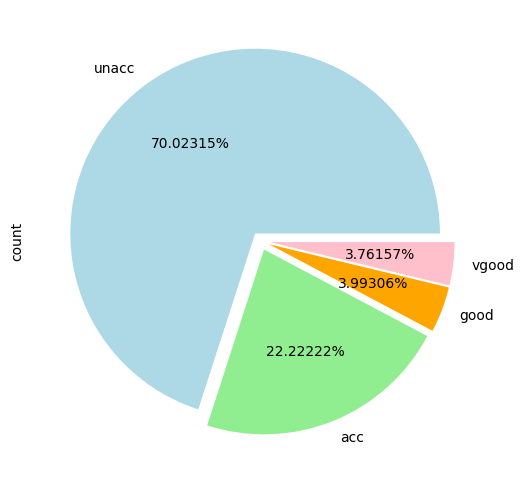

In [18]:
fig_size=plt.rcParams["figure.figsize"]
fig_size[0]=8
fig_size[1]=6
plt.rcParams['figure.figsize']=fig_size
dataset.output.value_counts().plot(kind='pie', autopct='%0.05f%%', colors=['lightblue','lightgreen', 'orange','pink' ], explode=(0.05, 0.05, 0.05, 0.05))

결과에 따르면 대부분의 자동차(70%)는 허용 불가능한 상태에 있고 20%만 허용 가능한 수준입니다. 즉, 양호한 상태의 자동차 비율이 매우 낮은 것을 볼 수 있습니다. 예제 데이터 정보를 확인했으니 본격적으로 데이터에 대한 전처리를 해봅시다. 딥러닝은 통계 알고리즘을 기반으로 하기 때문에 단어를 숫자(텐서)로 변환해야 합니다. 가장 먼저 필요한 전처리는 데이터를 파악하는 것입니다. 주어진 데이터의 형태를 파악한 후 숫자로 변환해주어야 하는데, 예제에서 다루는 데이터의 칼럼들은 모두 범주형 데이터(예. 성별: 여자, 남자)로 구성되어 있습니다. 다음 코드로 단어를 배열로 변환하는 방법에 대해 간단히 살펴보겠습니다. 이제 분석하지 좋게 데이터를 고치는 데이터 전처리를 해야 합니다. 먼저 astype()메서드를 이용하여 범주 특성을 갖는 데이터를 범주형 타입으로 변환합니다, 또한, 파이토치를 이용한 모델 학습을 해야 하므로 범주형 타입을 텐서로 변환해야 합니다. 참고로 이번 예제에서 사용하는 데이터는 모두 범주형 데이터입니다.

In [21]:
categorical_columns = [ 'price', 'maint' ,'doors' ,'persons','lug_capacity' , 'safety']
for category in categorical_columns:
  dataset[category] = dataset[category].astype( 'category' )

price = dataset[ 'price' ] .cat.codes.values
maint = dataset[ 'maint' ] .cat.codes.values
doors = dataset[ 'doors' ] .cat.codes.values
persons = dataset[ 'persons' ] .cat.codes.values
lug_capacity = dataset[ 'lug_capacity' ] .cat.codes.values
safety = dataset[ 'safety' ] .cat.codes.values

categorical_data = np.stack([price, maint, doors , persons, lug_capacity, safety] , 1)
categorical_data [ : 10 ]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

범주형 데이터를 텐서로 변환하기 위해 다음과 같은 절차가 필요합니다.
- 범주형 데이터 -> dataset[category] -> 넘파이 배열 -> 텐서

즉, 파이토치로 모델을 학습시키기 위해서는 텐서 형태로 변환해야 하는데, 넘파이 배열을 통해 텐서를 생성할 수 있습니다. 범주형 데이터(단어)를 숫자(넘파이 배열)로 변환하기 위해 cat.codes를 사용합니다. cat.codes는 어떤 클래스가 어떤 숫자로 매핑되어 있는지 확인이 어려운 단점이 있으므로 주의해서 사용해야 합니다. np.stack은 두 개 이상의 넘파이 객체를 합칠 떄 사용합니다.

- np.stack과 np.concatenate: 넘파이 객체를 합칠 때 사용하는 메서드로는 np.stack과 np.concatenate가 있습니다. 이 두 메서드는 차원의 유지 여부에 대한 차이가 있습니다. np.concaenate는 다음 그림과 같이 선택한 축을 기준으로 두 개의 배열을 연결합니다.
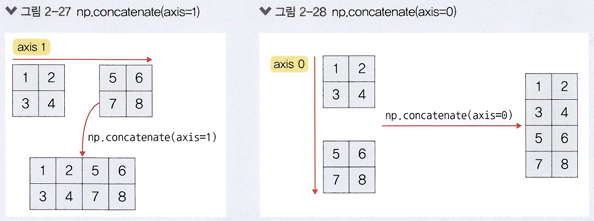

하지만 np.stack은 배열들을 새로운 축으로 합쳐 줍니다. 예를 들어 1차원 배열들을 합쳐서 2차원 배열을 만들거나 2차원 배열 여러 개를 합쳐 3차원 배열을 만듭니다. 따라서 반드시 두 배열의 차원이 동일해야 합니다.
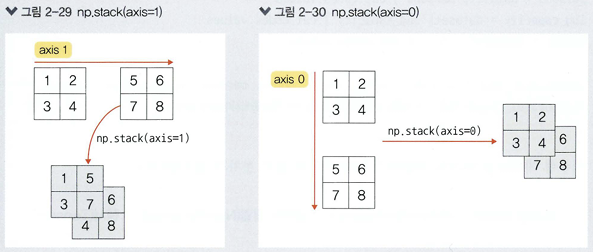

코드를 통해서 둘의 차이를 다시 살펴봅시다. 먼저 임의의 넘파이 배열 a,b,c를 정의합니다. 이때 c는 다른 차원으로 정의합니다. 이후 같은 차원을 갖는 a와 b에 대해 np.concatenate와 np.stack을 적용해보겠습니다.

In [22]:
a=np.array([[1,2],[3,4]])
b=np.array([[5,6],[7,8]])
c=np.array([[5,6],[7,8],[9,10]])

print(np.concatenate((a,b), axis=0))
print('-----------------------------')
print(np.stack((a,b), axis=0))

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
-----------------------------
[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]


다음은 np.concatenate와 np.stack을 적용한 결과입니다. 차원이 같기 때문에 오류 없이 결과를 출력하고 있으며, np.stack의 경우에는 (2,2,2)로 차원이 변경된 것을 확인할 수 있습니다. 이번에는 서로 다른 차원을 합쳐봅시다. 먼저 np.concatenate를 적용합니다.

In [23]:
print(np.concatenate((a,c), axis=0))

[[ 1  2]
 [ 3  4]
 [ 5  6]
 [ 7  8]
 [ 9 10]]


이번에는 np.stack을 적용합니다.

In [24]:
print(np.stack((a,c), axis=0))

ValueError: all input arrays must have the same shape

np.stack은 합치려는 두 넘파이 배열의 차원이 다르기 때문에 오류가 발생합니다.

이제 torch 모듈을 이용하여 배열을 텐서로 변환합니다.

In [25]:
categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

텐서로 변환된 결과에 대한 열 개의 결과를 살펴보면 다음과 같습니다. 마지막으로 레이블(outputs)로 사용할 칼럼에 대해서도 텐서로 변환해줍니다, 이번에는 get_dummies를 이용하여 넘파이 배열로 변환합니다.

In [26]:
outputs = pd.get_dummies (dataset.output)
outputs = outputs.values
outputs = torch.tensor(outputs).flatten()  #1차원 텐서로 변환

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


get_dummies는 가변수로 만들어 주는 함수입니다. 가변수로 만들어 준다는 의미는 문자를 숫자(0,1)로 바꾸어 준다는 의미입니다, 예를 위해 성별, 몸무게, 국적이라는 칼럼을 갖는 배열을 생성해보겠습니다.

In [27]:
import pandas as pd
import numpy as np
data = { 'gender' : [ 'male', 'female', 'male'], 'weight': [72, 55,68], 'nation': ['Japan','Korea','Australia' ]}
df = pd .DataFrame(data)
df

,gender,weight,nation
0,male,72,Japan
1,female,55,Korea
2,male,68,Australia


성별과 국적을 숫자로 변환하기 위해 get_dummies()를 적용합니다. 원래 숫자의 값을 가졌던 몸무게는 변화가 없
고 성별과 국적만 0과 1로 변경된 것을 확인할 수 있습니다.

In [28]:
pd.get_dummies(df)

,weight,gender_female,gender_male,nation_Australia,nation_Japan,nation_Korea
0,72,False,True,False,True,False
1,55,True,False,False,False,True
2,68,False,True,True,False,False


- ravel(), reshape(), flatten()
ravel(), reshape(), flatten()은 텐서의 차원을 바꿀 때 사용합니다. 이 메서드들은 다음과 같이 사용할 수 있습니다. 코드를 실행하면 다음과 같이 2차원 텐서가 1차원으로 변경되어 출력됩니다.

In [29]:
a = np .array([[1, 2], [3, 4]])
print(a.ravel())
print(a.reshape(-1))
print(a.flatten( ))

[1 2 3 4]
[1 2 3 4]
[1 2 3 4]


워드 임베딩은 유사한 단어끼리 유사하게 인코딩되도록 표현하는 방법입니다. 또한, 높은 차원의 임베딩일수록 단어 간의 세부적인 관계를 잘 파악할 수 있습니다. 따라서 단일 숫자로 변환된 넘파이 배열을 N차원으로 변경하여 사용합니다. 배열을 N차원으로 변환하기 위해 먼저 모든 범주형 칼럼에 대한 임베딩 크기(벡터 차원)를 정의합니다. 임베딩 크기에 대한 정확한 규칙은 없지만, 칼럼의 고유 수를 2로 나누는 것을 많이 사용합니다. 예를 들어 price 칼럼은 제 개의 고유 값을 갖기 때문에 임베딩 크기는 4/2=2입니다. 다음 코드를 이용하여 (모든 범주형 칼럼의 고유 값 수, 차원의 크기) 형태로 배열을 만듭니다.

In [35]:
categorical_column_sizes = [len(dataset[column].cat.categories) for column in categorical_columns]
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for col_size in categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


(모든 범주형 칼럼의 고유 값 수, 차원의 크기) 형태의 배열을 출력한 결과입니다.
데이터셋을 훈련과 테스트 용도로 분리합니다.

In [38]:
total_records = 1728
test_records = int(total_records * .2) # 전체 데이터 중 20%를 테스트 용도로 사용
categorical_train_data = categorical_data[:total_records - test_records]
categorical_test_data = categorical_data[total_records - test_records:total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

데이터를 훈련과 테스트 용도로 올바르게 분할했는지 확인하기 위해 레코드 개수를 출력해보겠습니다.

In [39]:
print(len (categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


데이터 준비가 끝났으므로, 모델 네트워크를 생성합니다.

In [68]:
class Model(nn.Module):
    def __init__(self, embedding_size, output_size, layers, p=0.4):
        super().__init__()
        self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in embedding_size])
        self.embedding_dropout = nn.Dropout(p)

        all_layers = []
        num_categorical_cols = sum((nf for ni, nf in embedding_size))
        input_size = num_categorical_cols # 입력층의 크기를 찾기 위해 범주형 칼럼 계수를 input_size 변수에 저장

        for i in layers:
            all_layers.append(nn.Linear(input_size, i))
            all_layers.append(nn.ReLU(inplace=True))
            all_layers.append(nn.BatchNorm1d(i))
            all_layers.append(nn.Dropout(p))
            input_size = i

        all_layers.append(nn.Linear(layers[-1], output_size))
        self.layers = nn.Sequential(*all_layers) # 신경망의 모든 계층이 순차적으로 실행되도록 모든 계층에 대한 목록(all_layers)을 nn.Sequential 클래스로 전달

    def forward(self, x_categorical):
        embeddings = []
        for i, e in enumerate(self.all_embeddings):
            embeddings.append(e(x_categorical[:, i]))

        x = torch.cat(embeddings, 1) # 넘파이의 concatenate와 같지만 대상이 텐서가 됨
        x = self.embedding_dropout(x)
        x = self.layers(x)
        return x

- 클래스 형태로 구현되는 모델은 nn.Module을 상속받습니다.
- __init__()은 모델에서 사용될 파라미터와 신경망을 초기화하기 위한 용도로 사용하며, 객체가 생성될 때 자동으로 호출됩니다. __init__()에서 전달되는 매개변수는 다음과 같습니다.
def __init__(self,embedding_size, output_size, layers, p=0.4)
 + self: 첫 번째 파라미터는 self를 지정해야 하며 자기 자신을 의미합니다. 예를 들어 ex라는 함수가 있을 때 self 의미는 다음 그림과 같습니다.
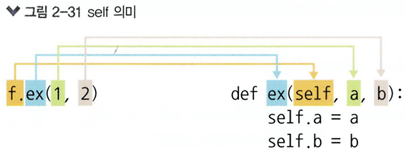
 + embedding_size: 범주형 칼럼의 임베딩 크기
 + output_size: 출력층의 크기
 + layers: 모든 계층에 대한 목록
 + p: 드롭아웃(기본값은 0.5)
- super().__init__()은 부모 클래스(nn.Module)에 접근할 때 사용합니다.
- 모델의 네트워크 계층을 구축하기 위해 for문을 이용하여 각 계층을 all_layers 목록에 추가합니다. 추가된 계층은 다음과 같습니다.
 + Linear: 선형 계층은 입력 데이터에 선형 변환을 진행한 결과입니다. 선형 변환을 위해서는 다음 수식을 사용합니다.
 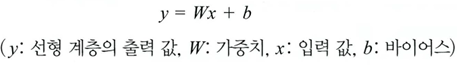
 따라서 선형 계층은 입력과 가중치를 곱한 후 바이어스를 더한 결과입니다.
  + ReLU: 활성화 함수로 사용
  + BatchNorm1d: 배치정규화 용도로 사용
  + Dropout: 과적합 방지에 사용
- forward() 함수는 학습 데이터를 입력받아서 연산을 진행합니다. forward() 함수는 모델 객체를 데이터와 함께 호출하면 자동으로 실행됩니다.

모델 훈련을 위해 앞에서 정의했던 Model 클래스의 객체를 생성합니다. 객체를 생성하면서 (범주형 칼럼의 임베딩 크기, 출력 그키, 은닉층 뉴런, 드롭아웃)을 전달합니다. 여기에서는 은닉층 [200,100,50]으로 정의했지만 다른 크기로 지정하여 테스트해 보는 것도 학습하는 데 도움이 될 것입니다. 코드를 실행하면 모델에 대한 구조(네트워크)를 보여준다.


In [69]:
model =Model(categorical_embedding_sizes,4,[200,100,50],p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


모델을 훈련시키기 전에 손실 함수와 옵티마이저에 대해 정의해야 합니다. 이번 예제는 데이터를 분류해야 하는 것으로 크로스 엔트로피 손실 함수를 사용합니다, 또한 옵티마이저로는 아담을 사용합니다.

In [70]:
loss_function=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(), lr=0.001)

파이토치는 GPU에 최적화된 딥러닝 프레임워크입니다. 하지만 GPU가 없다면 CPU를 사용할 수 있도록 지정해주어야 합니다. 다음은 GPU가 있다면 GPU를 사용하고, 없다면 CPU를 사용하도록 하는 코드입니다.

In [71]:
if torch.cuda.is_available():
  device = torch.device('cuda') # GPU가 있다면 GPU를 시용
else:
  device = torch.device('cpu') #GPU가 없다면 CPU를 사용

모델 훈련에 필요한 모든 준비가 완료되었습니다. 이제 준비된 데이터를 이용하여 모델을 학습시킵니다. 코드를 실행하면 25 에포크마다 출력된 오차 정보를 보여 줍니다.

In [72]:
epochs = 500
aggregated_losses = []

train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range(epochs):  # for문은 500회 반복되며, 각 반복마다 손실 함수가 오차를 계산
    i += 1
    y_pred = model(categorical_train_data).to(device)
    single_loss = loss_function(y_pred, train_outputs)
    aggregated_losses.append(single_loss) # 반복할 때마다 오차를 aggregated_losses에 추가

    if i % 25 == 1:
        print(f'epoch: {i:3}  loss: {single_loss.item():10.8f}')

    optimizer.zero_grad()
    single_loss.backward()  # 가준치 업데이트하기 위해 손실 함수의 backward() 메서드 호출
    optimizer.step()        # 옵티마이저 함수의 step() 메서드를 사용하여 기울기 업데이트

print(f'epoch: {i:3}  loss: {single_loss.item():10.10f}') # 오차가 25 에포크마다 출력

epoch:   1  loss: 1.50450134
epoch:  26  loss: 1.36226070
epoch:  51  loss: 1.27815640
epoch:  76  loss: 1.16973007
epoch: 101  loss: 1.04151642
epoch: 126  loss: 0.92524558
epoch: 151  loss: 0.82392418
epoch: 176  loss: 0.73029822
epoch: 201  loss: 0.69121104
epoch: 226  loss: 0.65958989
epoch: 251  loss: 0.63991272
epoch: 276  loss: 0.61908871
epoch: 301  loss: 0.59403908
epoch: 326  loss: 0.60272586
epoch: 351  loss: 0.59628022
epoch: 376  loss: 0.58786958
epoch: 401  loss: 0.58643848
epoch: 426  loss: 0.58157241
epoch: 451  loss: 0.58113843
epoch: 476  loss: 0.57313514
epoch: 500  loss: 0.5704071522


학습이 끝났으므로 데스트 데이터셋으로 예측을 진행해봅시다. 앞에서 준비했던 categorical_test_data 데이터셋을 모델에 적용합니다.

In [74]:
test_outputs = test_outputs.to(device=device, dtype=torch.int64)
with torch.no_grad():
  y_val = model(categorical_test_data)
  loss = loss_function(y_val, test_outputs)
print(f'Loss: {loss:.8f}' )

Loss: 0.56781501


코드를 실행하면 테스트 용도의 데이터셋에 대한 손실 값을 보여 줍니다. 이 값은 훈련 데이터셋에서 도출된 손실 값과 비슷하므로 과적합은 발생하지 않았다고 판단할 수 있다. 이제 테스트 데이터셋을 이용했을 때 모델이 얼마나 잘 예측하는지 살펴봅시다. 앞에서 모델 네트워크의 ouput_size에 4를 저장했습니다. 즉, 출력층에 네 개의 뉴런이 포함되도록 지정했으므로 각 예측에는 네 개의 값이 포함될 것입니다.

In [75]:
print(y_val [ : 5])

tensor([[ 3.6175,  2.2058, -3.8284, -3.8515],
        [ 2.8514,  1.7320, -3.9104, -3.8480],
        [ 2.5002,  1.6299, -3.4772, -3.5924],
        [ 5.7071,  4.0686, -6.0233, -5.5288],
        [ 2.5158,  1.4663, -2.8012, -2.9566]])


모델이 얼마나 잘 예측하는지 확인하기 위해 처음 다섯 개의 값을 출력하면 다음과 같습니다. 값이 출력되었지만 어떤 의미인지 이해하기 어려워 보입니다. 실제 출력이 0이면 인덱스 0(3.6175)의 값이 인덱스1(2.2058)의 값보다 높아야 합니다. 따라서 다음과 같은 코드를 이용하여 목록에서 가장 큰 값을 갖는 인덱스를 알아봅시다, 다시 말하지만 실제 값이 아닌 인덱스를 찾는 것입니다.

In [76]:
y_val = np.argmax(y_val, axis=1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


그러면 y_val에서 처음 다섯 개의 값이 출력되었습니다. 출력 결과 모두 인덱스 0이 출력되었습니다. 즉, 인덱스가 0인 값이 인덱스가 1인 값보다 크므로 처리된 출력이 0임을 확인할 수 있습니다. 마지막으로 sklearn.metrics 모듈의 classification_report, confusion_matrix, accuracy_score 클래스를 사용하여 정확도, 정밀도와 재현율을 알아봅시다.

In [77]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(test_outputs,y_val) )
print(classification_report(test_outputs, y_val))
print(accuracy_score(test_outputs, y_val))

[[257   2]
 [ 85   1]]
              precision    recall  f1-score   support

           0       0.75      0.99      0.86       259
           1       0.33      0.01      0.02        86

    accuracy                           0.75       345
   macro avg       0.54      0.50      0.44       345
weighted avg       0.65      0.75      0.65       345

0.7478260869565218


신경망에서 필요한 모든 파라미터를 무작위로 선택했다는 것을 감안할때 74%의 정확도는 나쁘지 않습니다. 파라미터(예. 훈련/테스트 데이터셋 분할, 은닉층 개수 및 크기 등)을 변경하면서 더 나은 성능을 찾아보는 것도 학습에 도움이 될 것입니다. 마지막으로 딥러닝 분류 모델의 성능 평가 지표를 알아보겠습니다. 성능 평가 지표로 정확도, 재현율, 정밀도, F1-Score가 있습니다. 정확도를 살펴보기 전에 필요한 용어들부터 살펴보겠습니다.
- True Positive: 모델(분류기)이 1이라고 예측했는데 실제 값도 1인 경우
- True Negative: 모델(분류기)이 0이라고 예측했는데 실제 값도 0인 경우
- False Positive: 모델(분류기)이 1이라고 예측했는데 실제 값은 0인 경우로, Type1 오류 라고도 한다.
- False Negative: 모델(분류기)이 0이라고 예측했는데 실제 값은 1인 경우로, Type2 오류 라고도 한다.


#### 정확도
전체 건수에서 정답을 맞힌 건수의 비율입니다. 이때 맞힌 정답이 긍정이든 부정이든 상관없습니다.
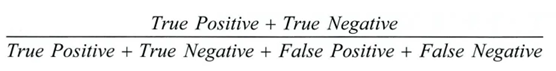

#### 재현율
실제 정답이 1이라고 할 때 모델(분류기)도 1로 예측한 비율입니다. 따라서 처음부터 데이터가 1일 확률이 적을 떄 사용하면 좋습니다.
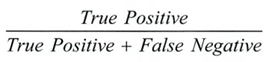

#### 정밀도
모델(분류기)이 1이라고 예측한 것 중에서 실제로 정답이 1인 비율입니다.
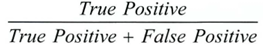

#### F1-Score
일반적으로 정밀도와 재현율은 트레이드오프 관계입니다. 정밀도가 높으면 재현율이 낮고, 재현율이 높으면 정밀도가 낮습니다. 이러한 트레이드오프 문제를 해결하고 정밀도와 재현율의 조화 평균을 이용한 것이 F1-Score 평가입니다.
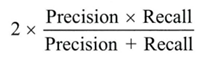